# Multi-Country Climate Analysis (Ethiopia, Kenya, Nigeria, Tanzania, Sudan)

Prepared by: Mariamawit Ewnetu Alemu  
Date: April 2026

---

## Executive Summary

This analysis explores climate patterns across five African countries using daily meteorological data from 2015 to 2026. The results highlight strong rainfall seasonality, variability in precipitation, and emerging temperature trends.

These findings provide insight into climate risks affecting agriculture, water systems, and environmental stability, supporting evidence-based policy discussions in preparation for COP32.

## Business Objective

EthioClimate Analytics has been engaged to support Ethiopia’s preparation for COP32 by producing clear, evidence-backed climate insights.

This analysis addresses three key questions:

1. What is changing in the climate data?
2. What risks or impacts could these changes suggest?
3. What policy or adaptation actions could the evidence support?

The goal is to move beyond exploratory charts and produce decision-support insights relevant to agriculture, water systems, drought preparedness, heat stress, and climate adaptation planning.

## From Data to Negotiation-Grade Evidence

- **What is changing:** Temperature trends, rainfall variability, extreme heat, and dry-day frequency  
- **What does it cause:** Increased agricultural risk, water stress, and heat exposure  
- **What does it demand:** Adaptation finance, early warning systems, drought resilience, and loss-and-damage support  

## Analytical Framework

This project follows a three-layer analytical framework:

1. **Data Layer** — Cleaning and structuring raw climate data  
2. **Analysis Layer** — Identifying patterns, trends, variability, and relationships  
3. **Insight Layer** — Translating results into real-world implications and policy-relevant findings  

This framework ensures the analysis moves beyond basic exploration toward practical climate-risk interpretation.

## Python Libraries

The following libraries are used for data cleaning, analysis, visualization, and statistical testing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress, kruskal

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Data Description

The dataset contains daily climate observations for five African countries:

- Ethiopia
- Kenya
- Nigeria
- Sudan
- Tanzania

Each row represents one day of weather data for a country.

Key variables include:

- `T2M` — mean daily temperature
- `T2M_MAX` — maximum daily temperature
- `T2M_MIN` — minimum daily temperature
- `T2M_RANGE` — daily temperature range
- `PRECTOTCORR` — daily precipitation
- `RH2M` — relative humidity
- `WS2M` — wind speed
- `WS2M_MAX` — maximum wind speed
- `PS` — surface pressure
- `QV2M` — specific humidity

The original dataset uses `YEAR` and `DOY` fields, which are converted into a proper date format for time-series analysis.

## Data Loading and Cleaning

All five country datasets are loaded using a consistent workflow.

The cleaning process includes:

- Adding a country label
- Replacing NASA missing-value placeholders (`-999`) with `NaN`
- Converting `YEAR` and `DOY` into a real date
- Creating `Month` and `YearMonth` features
- Checking duplicate records
- Forward-filling missing values where needed
- Exporting cleaned country-level datasets locally

The `data/` folder remains excluded from GitHub to avoid committing raw or cleaned CSV files.

In [2]:
countries = {
    "Ethiopia": "../data/ethiopia.csv",
    "Kenya": "../data/kenya.csv",
    "Nigeria": "../data/nigeria.csv",
    "Sudan": "../data/sudan.csv",
    "Tanzania": "../data/tanzania.csv"
}



Ethiopia: 0 duplicate rows
Kenya: 0 duplicate rows
Nigeria: 0 duplicate rows
Sudan: 0 duplicate rows
Tanzania: 0 duplicate rows


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,YearMonth
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1,2015-01
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1,2015-01
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1,2015-01
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1,2015-01
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1,2015-01


In [ ]:
from pathlib import Path

required_columns = [
    "YEAR", "DOY", "T2M", "T2M_MAX", "T2M_MIN",
    "T2M_RANGE", "PRECTOTCORR", "RH2M", "WS2M",
    "WS2M_MAX", "PS", "QV2M"
]

for country, path in countries.items():
    file_path = Path(path)

    if not file_path.exists():
        raise FileNotFoundError(f"Missing data file for {country}: {path}")

    preview_df = pd.read_csv(file_path, nrows=5)

    missing_cols = set(required_columns) - set(preview_df.columns)
    if missing_cols:
        raise ValueError(f"{country} dataset is missing columns: {missing_cols}")

In [ ]:
cleaned_dfs = []

for country, path in countries.items():
    df = pd.read_csv(path)
    df["Country"] = country
    
    # Replace missing-value placeholders
    df.replace(-999, np.nan, inplace=True)
    
    # Convert YEAR + DOY to proper date
    df["Date"] = pd.to_datetime(
        df["YEAR"] * 1000 + df["DOY"],
        format="%Y%j"
    )
    
    df["Month"] = df["Date"].dt.month
    df["YearMonth"] = df["Date"].dt.to_period("M").astype(str)
    
    # Check duplicates
    duplicate_count = df.duplicated().sum()
    print(f"{country}: {duplicate_count} duplicate rows")
    
    df.drop_duplicates(inplace=True)
    
    # Handle missing values
    df.ffill(inplace=True)
    
    # Export cleaned data locally
    df.to_csv(f"../data/{country.lower()}_clean.csv", index=False)
    
    cleaned_dfs.append(df)

climate_df = pd.concat(cleaned_dfs, ignore_index=True)

climate_df.head()

### Defensive Data Checks

Before loading the full datasets, each file path and required column set was checked. This prevents silent errors caused by missing files, changed column names, or incomplete datasets.

In [3]:
climate_df["Country"].unique()

array(['Ethiopia', 'Kenya', 'Nigeria', 'Sudan', 'Tanzania'], dtype=object)

In [4]:
missing_summary = climate_df.isna().sum()
missing_summary

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
YearMonth      0
dtype: int64

## Data Quality Summary

The datasets were checked for missing values and duplicate records. Missing-value placeholders were replaced with `NaN`, and duplicate rows were checked for each country.

This step is important because missing or duplicated data can distort averages, trends, rainfall distributions, and vulnerability rankings.

## Cross-Country Summary Statistics

Summary statistics are calculated to compare average temperature, rainfall, variability, maximum heat, and maximum rainfall across countries.

This provides a high-level view of climate differences before moving into trend and extreme-event analysis.

In [5]:
summary_table = climate_df.groupby("Country").agg(
    mean_temp=("T2M", "mean"),
    median_temp=("T2M", "median"),
    temp_std=("T2M", "std"),
    mean_max_temp=("T2M_MAX", "mean"),
    highest_temp=("T2M_MAX", "max"),
    mean_rainfall=("PRECTOTCORR", "mean"),
    median_rainfall=("PRECTOTCORR", "median"),
    rainfall_std=("PRECTOTCORR", "std"),
    highest_rainfall=("PRECTOTCORR", "max"),
    mean_humidity=("RH2M", "mean"),
    mean_wind_speed=("WS2M", "mean")
).reset_index()

summary_table

,Country,mean_temp,median_temp,temp_std,mean_max_temp,highest_temp,mean_rainfall,median_rainfall,rainfall_std,highest_rainfall,mean_humidity,mean_wind_speed
0,Ethiopia,16.068500,16.04,1.898050,23.199175,30.93,3.633795,0.82,6.289061,82.30,68.408588,1.979998
1,Kenya,20.427600,20.36,1.440824,27.838717,34.27,1.468162,0.38,3.180228,51.65,65.845355,3.061765
2,Nigeria,26.656928,26.82,1.123335,28.914667,32.88,4.213914,1.84,7.266742,166.10,85.237040,2.217135
3,Sudan,28.759007,29.16,4.681305,36.773914,45.96,0.643875,0.00,3.057672,66.49,31.359192,3.484253
4,Tanzania,26.802422,26.99,1.325388,29.163493,33.93,3.740256,0.64,8.003947,122.65,77.128038,4.105370


## Rainfall Distribution Across Countries

Rainfall distribution is analyzed using boxplots to compare precipitation variability across countries.

Rainfall is important because it relates directly to drought risk, flood risk, crop planning, water availability, and climate vulnerability.

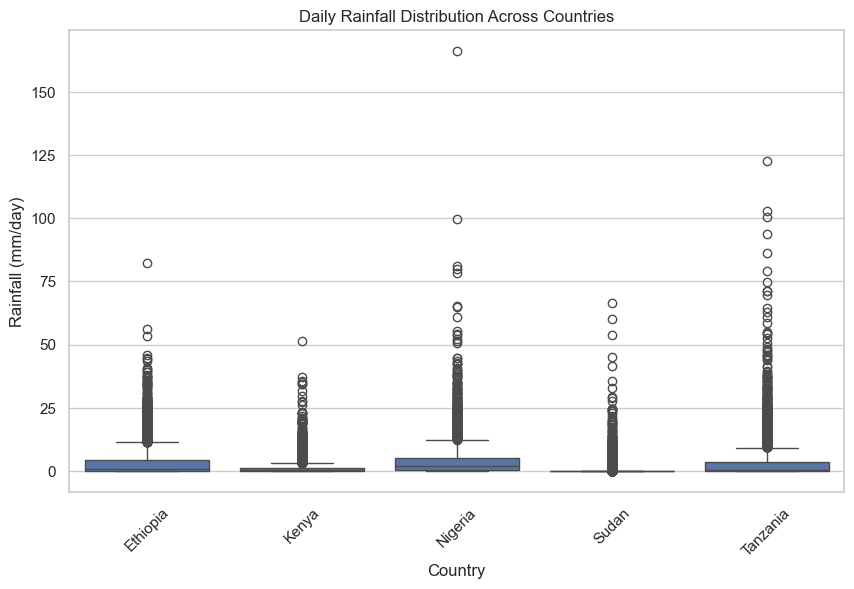

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=climate_df, x="Country", y="PRECTOTCORR")
plt.title("Daily Rainfall Distribution Across Countries")
plt.xlabel("Country")
plt.ylabel("Rainfall (mm/day)")
plt.xticks(rotation=45)
plt.show()

### Rainfall Interpretation

The rainfall distribution shows that precipitation is unevenly distributed across countries. Most days have low rainfall, while some countries experience occasional high-rainfall events.

This pattern suggests that rainfall is not constant throughout the year, but concentrated in specific seasons or extreme events. Such variability can create risks for agriculture, water management, and flood preparedness.

## Monthly Rainfall Seasonality

Monthly rainfall totals are analyzed to identify rainy seasons and compare seasonal rainfall patterns across countries.

This is important because agriculture and water planning often depend more on rainfall timing than annual totals alone.

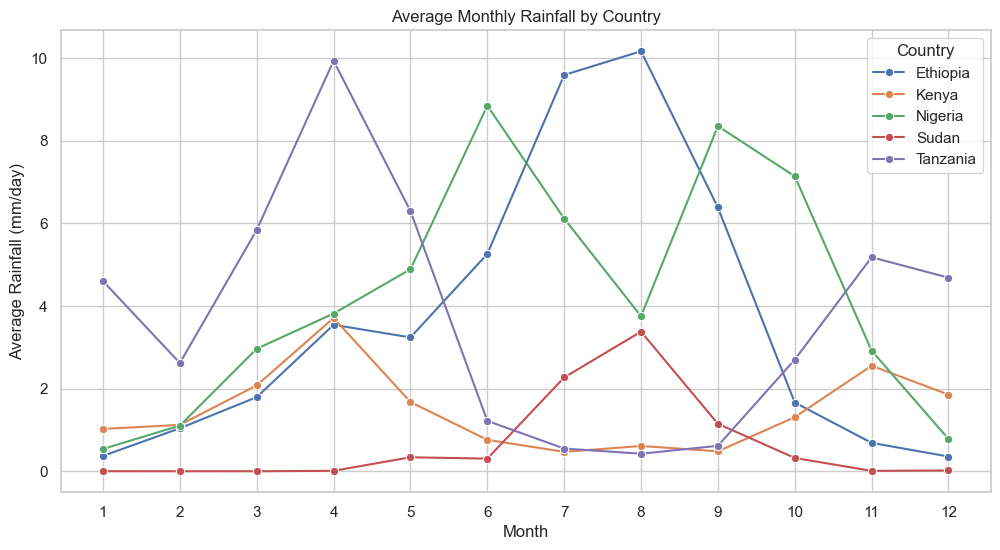

In [7]:
monthly_rainfall = climate_df.groupby(["Country", "Month"])["PRECTOTCORR"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_rainfall, x="Month", y="PRECTOTCORR", hue="Country", marker="o")
plt.title("Average Monthly Rainfall by Country")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm/day)")
plt.xticks(range(1, 13))
plt.show()

### Seasonal Rainfall Interpretation

The monthly rainfall pattern helps identify when rainfall is concentrated during the year. Countries with strong rainfall peaks may be more dependent on short rainy seasons.

This has important implications for farming calendars, irrigation planning, drought preparedness, and flood-risk management.

## Monthly Temperature Trend Comparison

Monthly average temperature is compared across all five countries from 2015 to 2026.

This helps identify seasonal temperature patterns and long-term warming signals.

monthly_temp = climate_df.groupby(["YearMonth", "Country"])["T2M"].mean().reset_index()
monthly_temp["YearMonth"] = pd.to_datetime(monthly_temp["YearMonth"])

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_temp, x="YearMonth", y="T2M", hue="Country")
plt.title("Monthly Average Temperature Across Countries (2015–2026)")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.show()

## Yearly Temperature Trend Analysis

Yearly average temperatures are calculated to reduce seasonal noise and better observe long-term temperature direction.

A simple linear regression is used for each country to estimate the warming trend in °C per year.

In [8]:
trend_results = []

for country in climate_df["Country"].unique():
    yearly_temp = (
        climate_df[climate_df["Country"] == country]
        .groupby("YEAR")["T2M"]
        .mean()
        .reset_index()
    )
    
    slope, intercept, r_value, p_value, std_err = linregress(
        yearly_temp["YEAR"],
        yearly_temp["T2M"]
    )
    
    trend_results.append({
        "Country": country,
        "Temperature Trend (°C/year)": slope,
        "Temperature Trend (°C/decade)": slope * 10,
        "P-value": p_value,
        "R-squared": r_value ** 2
    })

trend_table = pd.DataFrame(trend_results)
trend_table

,Country,Temperature Trend (°C/year),Temperature Trend (°C/decade),P-value,R-squared
0,Ethiopia,0.043127,0.431266,0.126259,0.217683
1,Kenya,0.016036,0.160364,0.597899,0.028814
2,Nigeria,0.087272,0.872716,0.013850,0.470053
3,Sudan,-0.145703,-1.457034,0.075739,0.281846
4,Tanzania,0.048548,0.485484,0.106437,0.239401


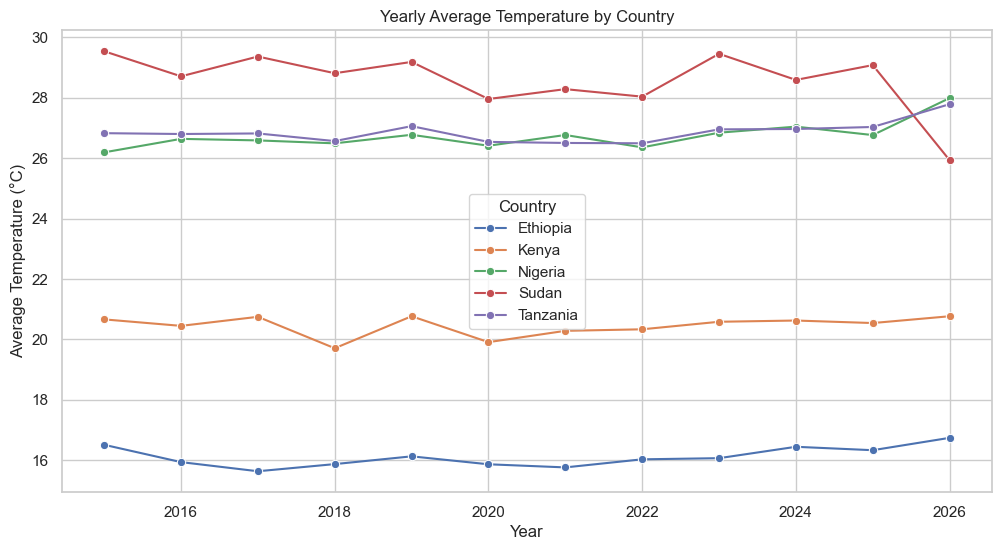

In [9]:
yearly_all = climate_df.groupby(["Country", "YEAR"])["T2M"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_all, x="YEAR", y="T2M", hue="Country", marker="o")
plt.title("Yearly Average Temperature by Country")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.show()

### Temperature Trend Interpretation

The trend table estimates the yearly change in average temperature for each country. A positive trend suggests warming, while the p-value helps assess whether the trend is statistically significant.

Even when trends are not statistically significant, positive warming directions can still be important from a climate-risk perspective, especially when combined with dry-day frequency, rainfall variability, and extreme heat exposure.

## Extreme Heat Days

Extreme heat days are defined as days where maximum temperature exceeds 35°C.

This indicator helps compare heat stress exposure across countries. Extreme heat can affect health, outdoor labor productivity, livestock, crops, and water demand.

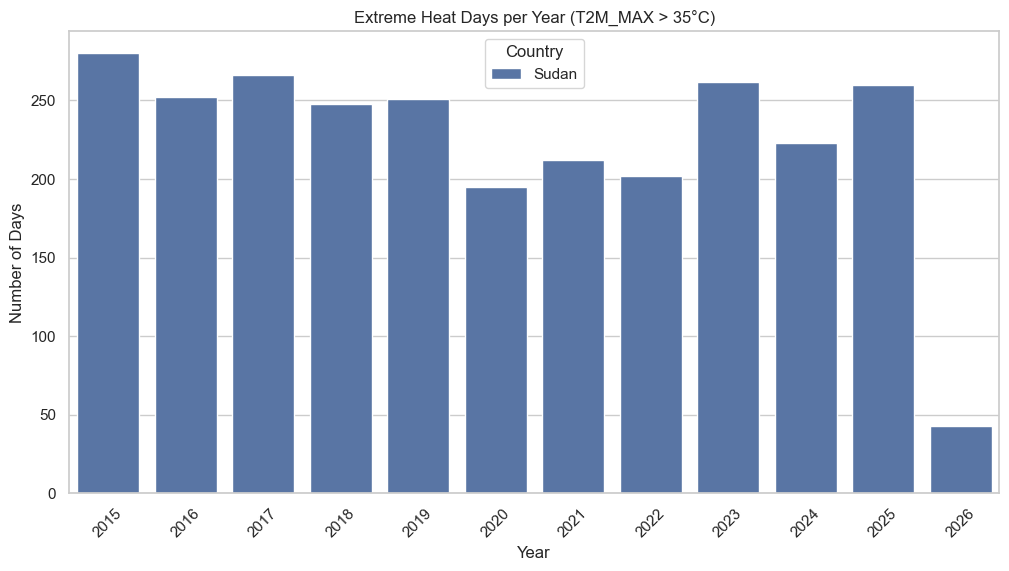

,Country,ExtremeHeatDays
0,Sudan,2694


In [10]:
extreme_heat = climate_df[climate_df["T2M_MAX"] > 35]

heat_days = (
    extreme_heat
    .groupby(["Country", "YEAR"])
    .size()
    .reset_index(name="ExtremeHeatDays")
)

plt.figure(figsize=(12, 6))
sns.barplot(data=heat_days, x="YEAR", y="ExtremeHeatDays", hue="Country")
plt.title("Extreme Heat Days per Year (T2M_MAX > 35°C)")
plt.xlabel("Year")
plt.ylabel("Number of Days")
plt.xticks(rotation=45)
plt.show()

heat_summary = (
    heat_days
    .groupby("Country")["ExtremeHeatDays"]
    .sum()
    .reset_index()
)

heat_summary

## Dry Days

Dry days are defined as days with rainfall below 1 mm.

This metric helps identify drought-related stress and rainfall reliability. A high number of dry days may indicate increased pressure on agriculture and water systems, especially in countries dependent on rain-fed farming.

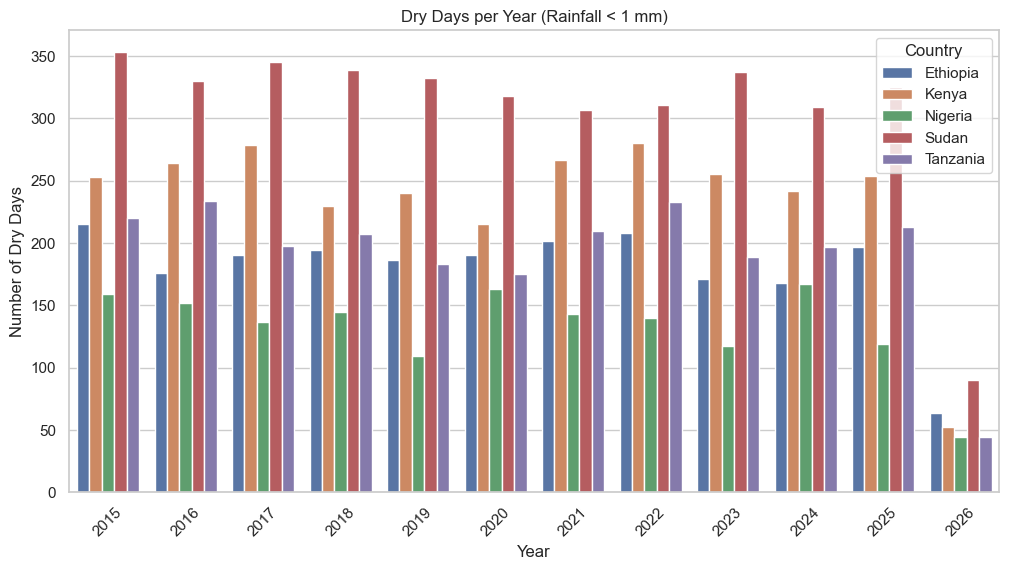

,Country,DryDays
0,Ethiopia,180.083333
1,Kenya,235.916667
2,Nigeria,132.916667
3,Sudan,308.000000
4,Tanzania,191.916667


In [11]:
dry_days = climate_df[climate_df["PRECTOTCORR"] < 1]

dry_day_counts = (
    dry_days
    .groupby(["Country", "YEAR"])
    .size()
    .reset_index(name="DryDays")
)

plt.figure(figsize=(12, 6))
sns.barplot(data=dry_day_counts, x="YEAR", y="DryDays", hue="Country")
plt.title("Dry Days per Year (Rainfall < 1 mm)")
plt.xlabel("Year")
plt.ylabel("Number of Dry Days")
plt.xticks(rotation=45)
plt.show()

dry_summary = (
    dry_day_counts
    .groupby("Country")["DryDays"]
    .mean()
    .reset_index()
)

dry_summary

## Correlation Analysis

Correlation analysis is used to understand how climate variables relate to each other.

This helps identify relationships such as:

- Temperature and humidity
- Rainfall and humidity
- Wind speed and temperature variability

These relationships provide insight into how different climate variables interact.

In [12]:
correlation_summary = []

for country in climate_df["Country"].unique():
    sub = climate_df[climate_df["Country"] == country]
    
    corr_temp_humidity = sub["T2M"].corr(sub["RH2M"])
    corr_rain_humidity = sub["PRECTOTCORR"].corr(sub["RH2M"])
    corr_range_wind = sub["T2M_RANGE"].corr(sub["WS2M"])
    
    correlation_summary.append({
        "Country": country,
        "Corr_Temp_Humidity": corr_temp_humidity,
        "Corr_Rain_Humidity": corr_rain_humidity,
        "Corr_TempRange_Wind": corr_range_wind
    })

correlation_table = pd.DataFrame(correlation_summary)
correlation_table

,Country,Corr_Temp_Humidity,Corr_Rain_Humidity,Corr_TempRange_Wind
0,Ethiopia,-0.194146,0.501347,0.541854
1,Kenya,-0.591085,0.469921,0.306106
2,Nigeria,-0.044055,0.348843,-0.418511
3,Sudan,0.041563,0.404591,-0.059890
4,Tanzania,0.124018,0.512770,0.139584


## Relationship Scatter Plots

Scatter plots are used to visually examine relationships between important climate variables.

The analysis focuses on:

- Temperature vs relative humidity
- Temperature range vs wind speed

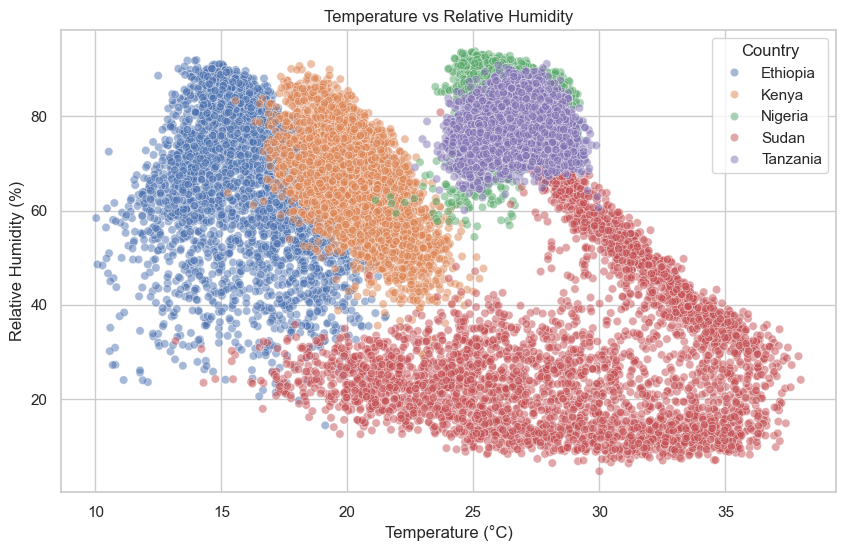

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=climate_df, x="T2M", y="RH2M", hue="Country", alpha=0.5)
plt.title("Temperature vs Relative Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.show()

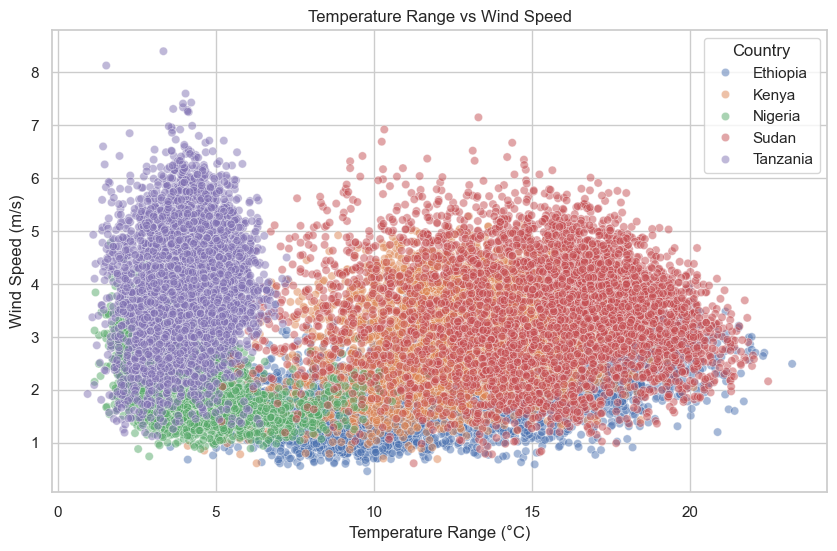

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=climate_df, x="T2M_RANGE", y="WS2M", hue="Country", alpha=0.5)
plt.title("Temperature Range vs Wind Speed")
plt.xlabel("Temperature Range (°C)")
plt.ylabel("Wind Speed (m/s)")
plt.show()

## Statistical Testing

A Kruskal-Wallis test is used to assess whether temperature distributions differ significantly across the five countries.

This non-parametric test is appropriate because climate data may not follow a normal distribution.

In [15]:
temperature_groups = [
    climate_df[climate_df["Country"] == country]["T2M"]
    for country in climate_df["Country"].unique()
]

statistic, p_value = kruskal(*temperature_groups)

print(f"Kruskal-Wallis statistic: {statistic:.3f}")
print(f"P-value: {p_value:.5f}")

Kruskal-Wallis statistic: 15392.992
P-value: 0.00000


### Statistical Test Interpretation

The Kruskal-Wallis test evaluates whether the temperature distributions differ across countries.

A small p-value suggests that at least one country has a significantly different temperature distribution compared with the others. This supports the need for country-specific climate adaptation strategies rather than a one-size-fits-all approach.

## Climate Vulnerability Ranking

An exploratory vulnerability score is created to compare countries using multiple climate stress indicators:

- Mean temperature
- Rainfall variability
- Temperature trend
- Extreme heat days
- Dry days

This ranking is not a definitive national vulnerability index. Instead, it is a practical comparison tool to support discussion of relative climate stress across countries.

In [16]:
ranking = summary_table.merge(trend_table, on="Country", how="left")
ranking = ranking.merge(heat_summary, on="Country", how="left")
ranking = ranking.merge(dry_summary, on="Country", how="left")

ranking["ExtremeHeatDays"] = ranking["ExtremeHeatDays"].fillna(0)
ranking["DryDays"] = ranking["DryDays"].fillna(0)

ranking["VulnerabilityScore"] = (
    ranking["mean_temp"].rank(ascending=True) +
    ranking["rainfall_std"].rank(ascending=True) +
    ranking["Temperature Trend (°C/year)"].rank(ascending=True) +
    ranking["ExtremeHeatDays"].rank(ascending=True) +
    ranking["DryDays"].rank(ascending=True)
)

ranking = ranking.sort_values("VulnerabilityScore", ascending=False)

ranking[
    [
        "Country",
        "mean_temp",
        "rainfall_std",
        "Temperature Trend (°C/year)",
        "ExtremeHeatDays",
        "DryDays",
        "VulnerabilityScore"
    ]
]

,Country,mean_temp,rainfall_std,Temperature Trend (°C/year),ExtremeHeatDays,DryDays,VulnerabilityScore
4,Tanzania,26.802422,8.003947,0.048548,0.0,191.916667,18.5
3,Sudan,28.759007,3.057672,-0.145703,2694.0,308.000000,17.0
2,Nigeria,26.656928,7.266742,0.087272,0.0,132.916667,15.5
1,Kenya,20.427600,3.180228,0.016036,0.0,235.916667,12.5
0,Ethiopia,16.068500,6.289061,0.043127,0.0,180.083333,11.5


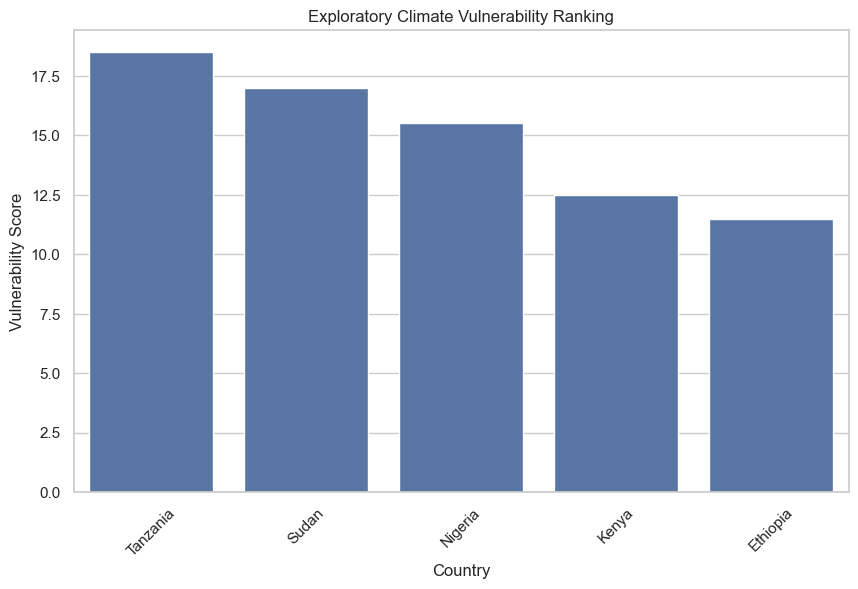

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ranking, x="Country", y="VulnerabilityScore")
plt.title("Exploratory Climate Vulnerability Ranking")
plt.xlabel("Country")
plt.ylabel("Vulnerability Score")
plt.xticks(rotation=45)
plt.show()

## Interpretation of Vulnerability Ranking

The ranking highlights different types of climate stress:

- Sudan shows heat-driven vulnerability due to extreme heat exposure  
- Nigeria shows combined rainfall variability and warming signals  
- Tanzania shows high rainfall variability  
- Kenya shows moderate variability with dry-day exposure  
- Ethiopia shows lower relative vulnerability but remains sensitive to seasonal rainfall changes  

This demonstrates that climate risk is multidimensional and country-specific.

## COP32-Framed Insights

1. **Temperature change:** Several countries show positive temperature trends, suggesting gradual warming patterns that should be monitored over longer time periods.

2. **Rainfall instability:** Rainfall is unevenly distributed, with many dry days and occasional intense rainfall events. This creates risks for both drought and flooding.

3. **Extreme heat and dry days:** Extreme heat exposure and dry-day frequency reveal climate stress that can affect agriculture, water availability, and public health.

4. **Ethiopia’s climate profile:** Ethiopia shows strong rainfall seasonality and moderate temperature patterns, but remains vulnerable because of dependence on seasonal rainfall.

5. **Policy implication:** The evidence supports investment in climate adaptation, early warning systems, drought preparedness, irrigation planning, and resilient agricultural systems.

## Key Insights

- Rainfall is highly seasonal and concentrated within specific months.
- Most countries experience many low-rainfall days, with occasional heavy rainfall events.
- Temperature trends show signs of gradual warming in several countries.
- Dry-day frequency is an important signal of drought-related climate stress.
- Extreme heat days reveal differences in heat exposure across countries.
- Temperature and humidity generally show an inverse relationship.
- Climate risks vary by country, supporting the need for localized adaptation strategies.

## Practical Implications

The findings suggest several important implications:

- Rain-fed agricultural systems are vulnerable to rainfall timing and variability.
- High dry-day frequency may increase drought stress and water demand.
- Extreme heat days may affect outdoor labor, livestock, crop productivity, and health.
- Seasonal forecasting and early warning systems are essential for preparedness.
- Climate adaptation finance should support irrigation, water storage, drought resilience, and flood preparedness.

These insights help translate climate data into practical decision support.

## **What This Means for COP32 Negotiation**

The analysis shows measurable warming trends, increasing rainfall variability, and rising climate instability across the five countries.

These patterns indicate growing pressure on agriculture, water systems, and heat exposure, particularly in regions dependent on seasonal rainfall.

This evidence strengthens the case for the following:

- Increased climate adaptation finance  
- Investment in early warning systems  
- Strengthening drought and flood resilience programs  
- Recognition of climate-related loss and damage  

Overall, the findings provide data-driven justification for stronger climate action and support Ethiopia’s role in presenting credible, evidence-based arguments at COP32.

## Strategic Positioning for COP32

This analysis positions Ethiopia as a data-informed host capable of presenting credible, evidence-based climate arguments.

The findings reinforce Africa’s case for increased adaptation finance, improved early warning systems, and stronger international support for climate resilience and loss-and-damage mechanisms.

Together, these insights strengthen Ethiopia’s ability to lead data-driven climate discussions at COP32.

## Conclusion

This multi-country climate analysis provides a comparative overview of climate patterns in Ethiopia, Kenya, Nigeria, Sudan, and Tanzania from 2015 to 2026.

The results show strong rainfall seasonality, uneven precipitation distribution, dry-day patterns, extreme heat exposure, and gradual warming signals. While trend significance varies by country, the combined evidence highlights important climate stress indicators.

The analysis supports the need for evidence-based adaptation planning, especially in agriculture, water resource management, drought preparedness, and early warning systems.

Overall, the findings demonstrate how climate data can be transformed into policy-relevant insights for COP32 preparation.

## Future Work

Future work could improve this analysis by:

- Extending the time period beyond 2015–2026
- Adding more African countries
- Comparing results with external impact data such as crop yield, displacement, or disease burden
- Building predictive models for temperature and rainfall
- Developing an interactive Streamlit dashboard
- Applying more advanced drought indices such as SPI or SPEI

In [18]:
summary_table.to_csv("../data/country_summary_table.csv", index=False)
trend_table.to_csv("../data/temperature_trend_table.csv", index=False)
ranking.to_csv("../data/vulnerability_ranking.csv", index=False)